Exploratory Data Analysis

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy

phot_data = pd.read_csv("string_phot_rat_data.csv")

In [26]:
phot_data.head()

,rat,percentage_x,x_pos_centered,y_pos_centered,x_reach_centered,y_reach_centered,df_centered,effort_centered,rot_centered,paw_vel_centered
0,5,0.00,0.566854,1.080798,0.566854,1.080798,-0.007717,0.033047,-9.731920,4.518823
1,5,0.01,0.407729,1.067616,0.407729,1.067616,-0.006712,0.028269,-9.729127,2.845532
2,5,0.02,0.271484,1.024612,0.271484,1.024612,-0.006235,0.030529,-9.726279,1.519936
3,5,0.03,0.169633,0.956670,0.169633,0.956670,-0.012567,0.040871,-9.723376,0.318620
4,5,0.04,0.095008,0.873968,0.095008,0.873968,-0.010752,0.029611,-9.720413,-0.967590


In [27]:
data = phot_data.drop(columns=['percentage_x', 'x_reach_centered', 'y_reach_centered'])
data = data.dropna()

In [28]:
data.head()

,rat,x_pos_centered,y_pos_centered,df_centered,effort_centered,rot_centered,paw_vel_centered
0,5,0.566854,1.080798,-0.007717,0.033047,-9.731920,4.518823
1,5,0.407729,1.067616,-0.006712,0.028269,-9.729127,2.845532
2,5,0.271484,1.024612,-0.006235,0.030529,-9.726279,1.519936
3,5,0.169633,0.956670,-0.012567,0.040871,-9.723376,0.318620
4,5,0.095008,0.873968,-0.010752,0.029611,-9.720413,-0.967590


In [29]:
data['rat'].unique()

array([ 5,  6, 25])

In [30]:
# one hot encode rat
encode_data = data.copy()
rat6 = data['rat'] == 6
rat25 = data['rat'] == 25
encode_data['rat6'] = rat6.astype(int)
encode_data['rat25'] = rat25.astype(int)
encode_data = encode_data.drop(columns='rat')

In [32]:
encode_data.head()


,x_pos_centered,y_pos_centered,df_centered,effort_centered,rot_centered,paw_vel_centered,rat6,rat25
0,0.566854,1.080798,-0.007717,0.033047,-9.731920,4.518823,0,0
1,0.407729,1.067616,-0.006712,0.028269,-9.729127,2.845532,0,0
2,0.271484,1.024612,-0.006235,0.030529,-9.726279,1.519936,0,0
3,0.169633,0.956670,-0.012567,0.040871,-9.723376,0.318620,0,0
4,0.095008,0.873968,-0.010752,0.029611,-9.720413,-0.967590,0,0


In [33]:
data.describe()

,rat,x_pos_centered,y_pos_centered,df_centered,effort_centered,rot_centered,paw_vel_centered
count,133405.000000,133405.000000,133405.000000,133405.000000,133405.000000,133405.000000,133405.000000
mean,10.658948,-0.000052,0.000423,0.000002,0.000005,-0.001624,0.010500
std,8.704463,0.784356,1.449613,0.008704,0.035087,11.868177,19.720254
min,5.000000,-3.574703,-8.416576,-0.057015,-0.184591,-33.687786,-52.749957
25%,5.000000,-0.605860,-1.097371,-0.004925,-0.019809,-8.556199,-10.683980
50%,6.000000,-0.038505,-0.018048,0.000003,0.000000,-1.523930,-5.200048
75%,25.000000,0.532695,0.984513,0.004918,0.021116,6.578422,2.438279
max,25.000000,2.898021,11.371711,0.080527,0.196711,78.544287,209.860118


Text(0.5, 1.0, 'X paw displacement distribution')

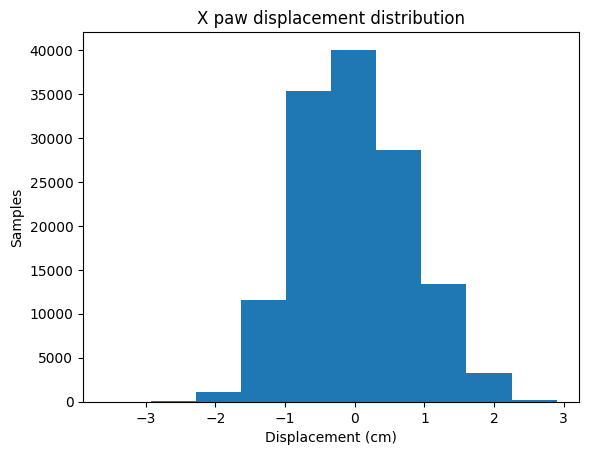

In [36]:
plt.hist(encode_data['x_pos_centered'])
plt.xlabel("Displacement (cm)")
plt.ylabel('Samples')
plt.title("X paw displacement distribution")

Text(0.5, 1.0, 'Y paw displacement distribution')

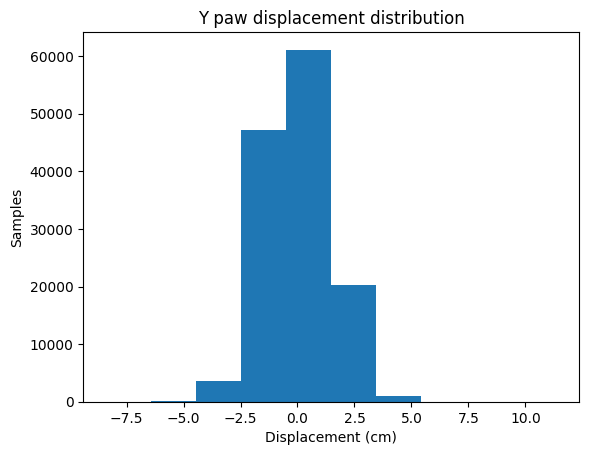

In [37]:
plt.hist(encode_data['y_pos_centered'])
plt.xlabel("Displacement (cm)")
plt.ylabel('Samples')
plt.title("Y paw displacement distribution")

Text(0.5, 1.0, 'Distribution of dopamine fluctuations')

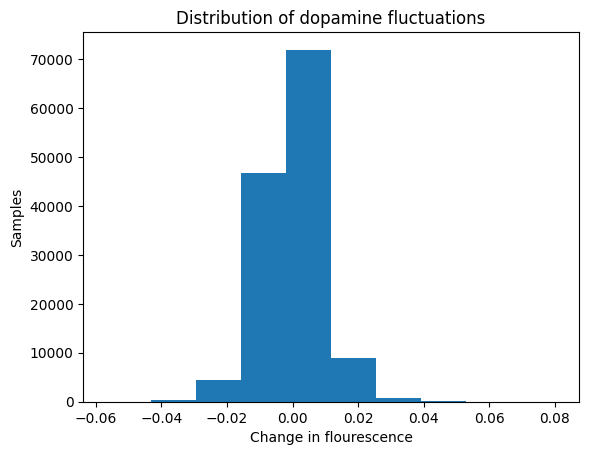

In [38]:
plt.hist(encode_data['df_centered'])
plt.xlabel("Change in flourescence")
plt.ylabel('Samples')
plt.title("Distribution of dopamine fluctuations")

Text(0.5, 1.0, 'Distribution of effort')

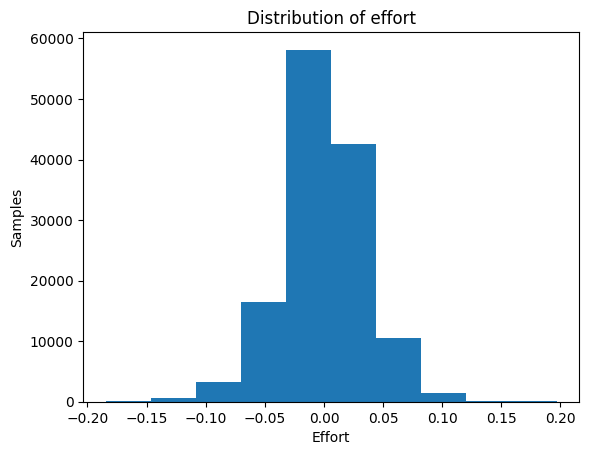

In [39]:
plt.hist(encode_data['effort_centered'])
plt.xlabel("Effort")
plt.ylabel('Samples')
plt.title("Distribution of effort")

Text(0.5, 1.0, 'Distribution of string speed')

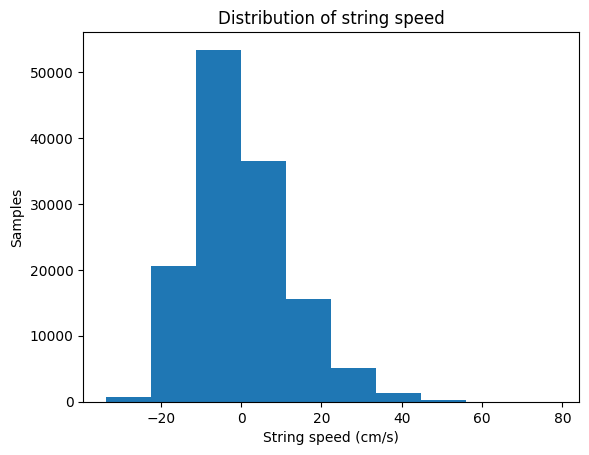

In [40]:
plt.hist(encode_data['rot_centered'])
plt.xlabel("String speed (cm/s)")
plt.ylabel('Samples')
plt.title("Distribution of string speed")

Text(0.5, 1.0, 'Distribution of paw velocity')

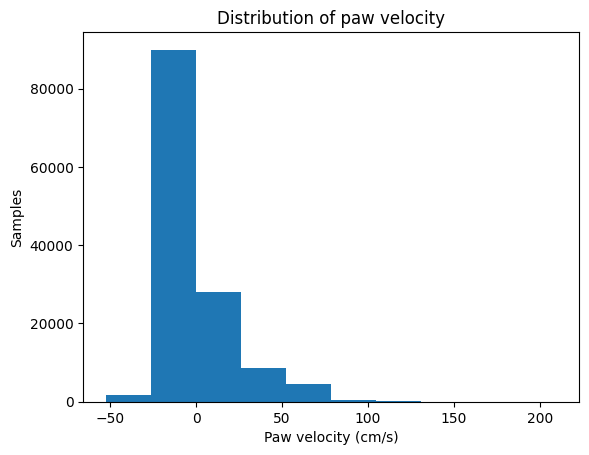

In [41]:
plt.hist(encode_data['paw_vel_centered'])
plt.xlabel("Paw velocity (cm/s)")
plt.ylabel('Samples')
plt.title("Distribution of paw velocity")

In [42]:
encode_data.corr()

,x_pos_centered,y_pos_centered,df_centered,effort_centered,rot_centered,paw_vel_centered,rat6,rat25
x_pos_centered,1.000000,0.473030,-0.136251,0.159627,0.423922,0.540767,0.000288,0.000040
y_pos_centered,0.473030,1.000000,-0.105896,-0.003439,0.155729,0.087917,-0.000126,-0.000177
df_centered,-0.136251,-0.105896,1.000000,-0.035536,-0.061100,-0.067915,0.000366,-0.000140
effort_centered,0.159627,-0.003439,-0.035536,1.000000,-0.187717,-0.005753,0.000149,-0.000087
rot_centered,0.423922,0.155729,-0.061100,-0.187717,1.000000,0.449407,0.000088,0.000083
paw_vel_centered,0.540767,0.087917,-0.067915,-0.005753,0.449407,1.000000,-0.000184,-0.000323
rat6,0.000288,-0.000126,0.000366,0.000149,0.000088,-0.000184,1.000000,-0.381437
rat25,0.000040,-0.000177,-0.000140,-0.000087,0.000083,-0.000323,-0.381437,1.000000


array([[<Axes: title={'center': 'df_centered'}, xlabel='[rat]'>,
        <Axes: title={'center': 'effort_centered'}, xlabel='[rat]'>],
       [<Axes: title={'center': 'paw_vel_centered'}, xlabel='[rat]'>,
        <Axes: title={'center': 'rot_centered'}, xlabel='[rat]'>],
       [<Axes: title={'center': 'x_pos_centered'}, xlabel='[rat]'>,
        <Axes: title={'center': 'y_pos_centered'}, xlabel='[rat]'>]],
      dtype=object)

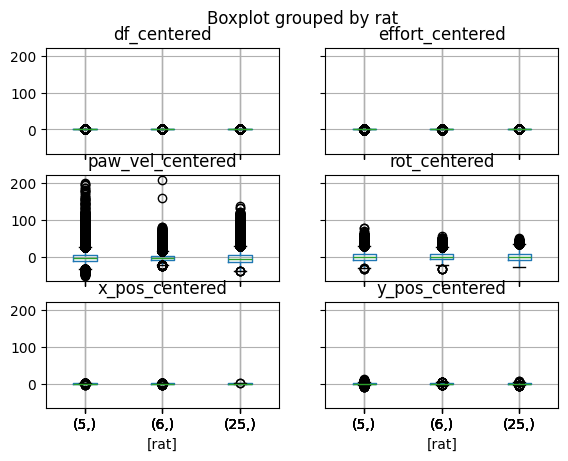

In [44]:
data.boxplot(by=['rat'])